# House Price Prediction — Regression Modeling & Ensembling

Predicts residential house prices from listing features (size, location, condition, age, etc.) using a Kaggle-style Seattle-area housing dataset.

**Approach:** clean and engineer features, explore the data, train and tune four models (Linear Regression, Random Forest, XGBoost, CatBoost), diagnose where errors concentrate, engineer a location-based feature to close part of that gap, and combine the two strongest models into a final ensemble.

**Final model:** an averaged XGBoost + CatBoost ensemble, selected after comparing all models on MAE, RMSE, and R², and confirming it improved on the worst-performing price segment identified during diagnostics.

## 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from category_encoders import TargetEncoder

import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

from catboost import CatBoostRegressor
import scipy.stats as stats

import pickle

## 2. Load Dataset

Load the raw housing data and check its shape before any cleaning.

In [2]:
df = pd.read_csv('../data/data.csv')

print(f"Original Shape: {df.shape}")
df.head()

Original Shape: (4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


## 3. Data Cleaning

Drop duplicate rows and any rows with missing values.

In [3]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

## 4. Feature Engineering

Drop columns that don't help the model (`country` has zero variance, `street` is too high-cardinality), and derive more useful features from the raw date and year fields: `house_age` at time of sale and a binary `is_renovated` flag.

In [4]:
# Drop Irrelevant or Overly Unique Columns
# 'country' has zero variance (all values are USA). 
# 'street' is too unique (high cardinality) and causes overfitting.
columns_to_drop = ['street', 'country']
df = df.drop(columns=columns_to_drop, errors='ignore')

df['date'] = pd.to_datetime(df['date'])
df['year_sold'] = df['date'].dt.year
df['month_sold'] = df['date'].dt.month

# Calculate the actual age of the house when it was sold
df['house_age'] = df['year_sold'] - df['yr_built']

# Create a binary indicator for whether the house has ever been renovated
df['is_renovated'] = df['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)

# Drop the raw date and year columns since we extracted their value
df = df.drop(columns=['date', 'yr_built', 'yr_renovated', 'year_sold'])

# We also want to filter out rows where price is 0 (sometimes present in raw data anomalies)
df = df[df['price'] > 0]

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4551 entries, 0 to 4599
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          4551 non-null   float64
 1   bedrooms       4551 non-null   float64
 2   bathrooms      4551 non-null   float64
 3   sqft_living    4551 non-null   int64  
 4   sqft_lot       4551 non-null   int64  
 5   floors         4551 non-null   float64
 6   waterfront     4551 non-null   int64  
 7   view           4551 non-null   int64  
 8   condition      4551 non-null   int64  
 9   sqft_above     4551 non-null   int64  
 10  sqft_basement  4551 non-null   int64  
 11  city           4551 non-null   object 
 12  statezip       4551 non-null   object 
 13  month_sold     4551 non-null   int32  
 14  house_age      4551 non-null   int64  
 15  is_renovated   4551 non-null   int64  
dtypes: float64(4), int32(1), int64(9), object(2)
memory usage: 586.7+ KB


## 5. Exploratory Data Analysis (EDA)

Visualize the target variable and key relationships before modeling.

### Price Distribution

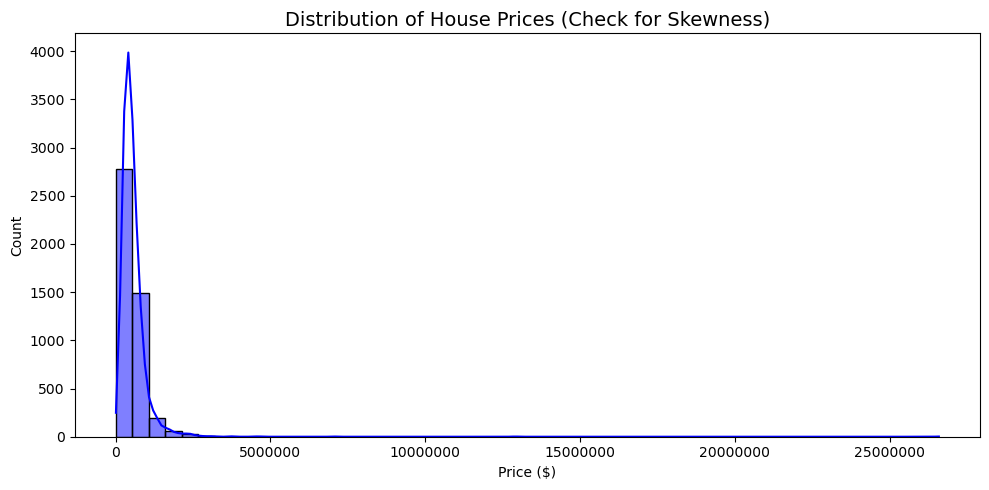

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True, color='blue')
plt.title('Distribution of House Prices (Check for Skewness)', fontsize=14)
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.ticklabel_format(style='plain', axis='x') # Prevents scientific notation
plt.tight_layout()
plt.savefig('../screenshots/price_distribution.png') # Saves chart automatically
plt.show()

### Handling Skewness

Raw price is right-skewed. Comparing outlier removal against a log transform shows log-transforming the target is the better fix, since it doesn't throw away real high-value homes.

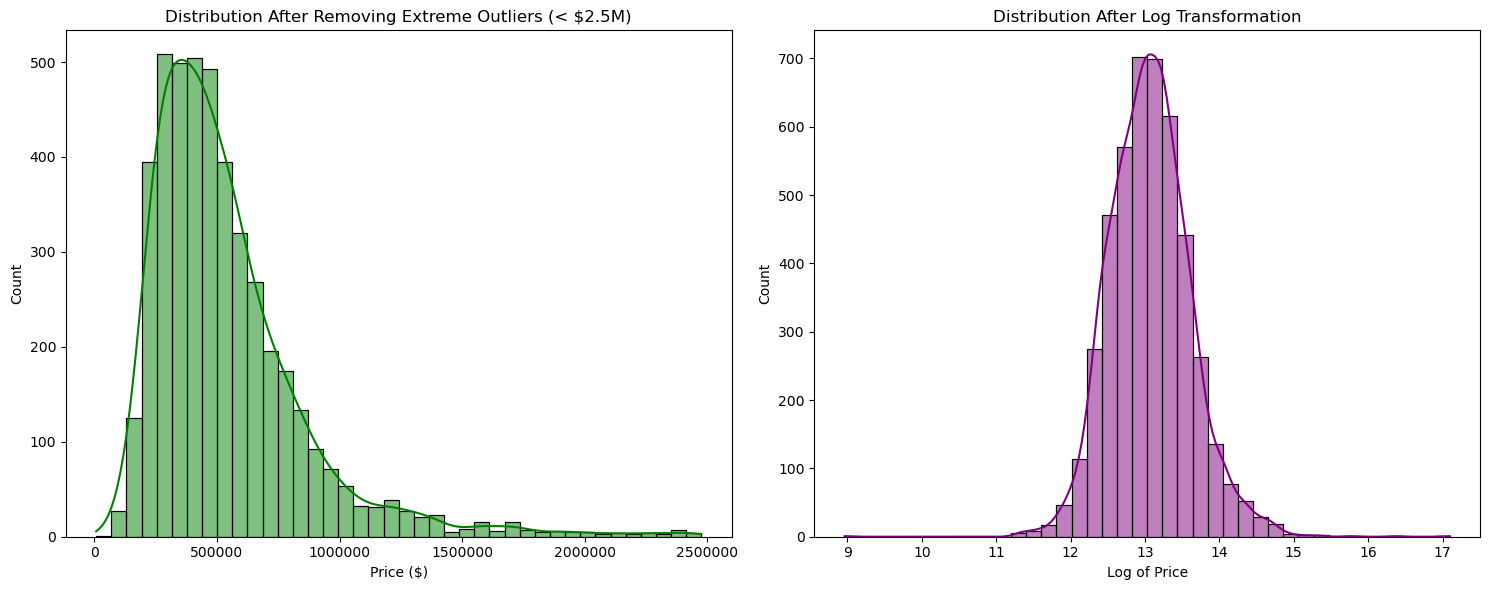

Original skewness: 25.02
Skewness after Log transformation: 0.33


In [6]:
# APPLY LOG TRANSFORMATION
# np.log1p handles log(x + 1) to prevent errors if there are zero values
df['log_price'] = np.log1p(df['price'])

# FILTER OUT EXTREME OUTLIERS (For alternative visualization)
# Let's say we want to look at houses under $2.5 Million to see the real distribution
standard_houses = df[df['price'] <= 2500000]

# PLOT THE COMPARISON
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left Plot: After Outlier Removal
sns.histplot(standard_houses['price'], bins=40, kde=True, color='green', ax=axes[0])
axes[0].set_title('Distribution After Removing Extreme Outliers (< $2.5M)', fontsize=12)
axes[0].set_xlabel('Price ($)')
axes[0].ticklabel_format(style='plain', axis='x')

# Right Plot: After Log Transformation
sns.histplot(df['log_price'], bins=40, kde=True, color='purple', ax=axes[1])
axes[1].set_title('Distribution After Log Transformation', fontsize=12)
axes[1].set_xlabel('Log of Price')

plt.tight_layout()
plt.savefig('../screenshots/transformed_distributions.png')
plt.show()

print(f"Original skewness: {df['price'].skew():.2f}")
print(f"Skewness after Log transformation: {df['log_price'].skew():.2f}")

### Correlation Matrix

Check which numeric features correlate most strongly with price.

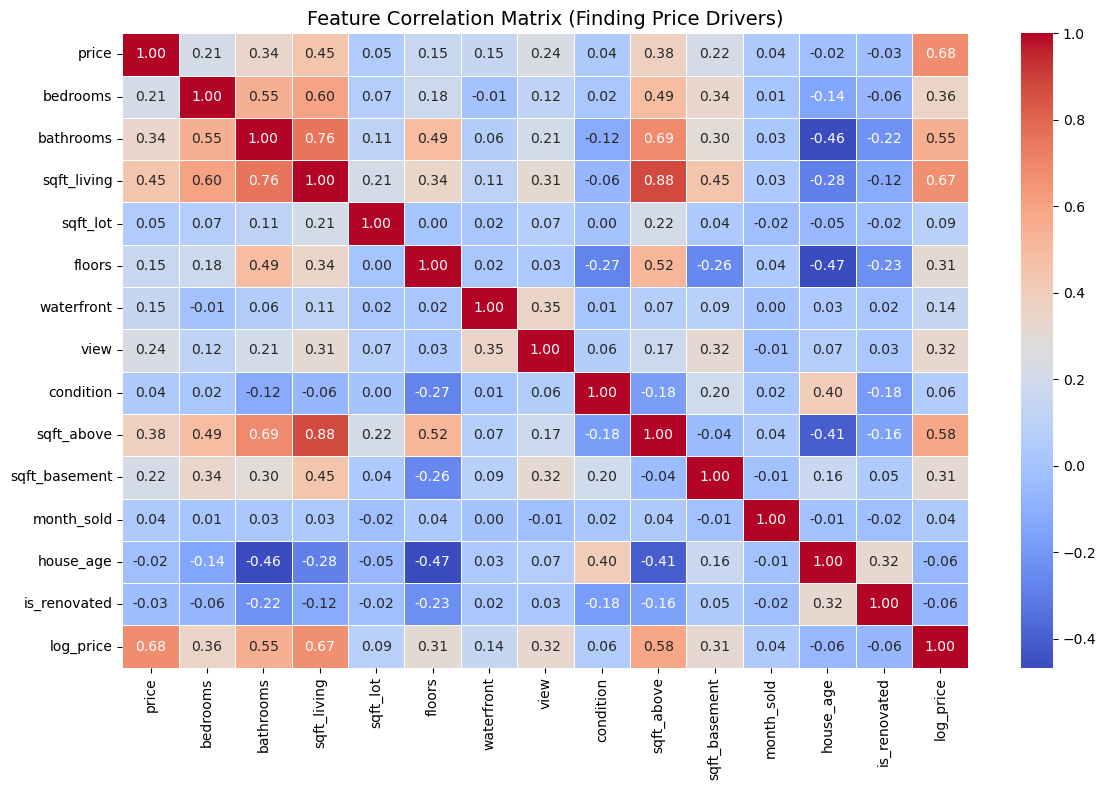

In [7]:
# Analyzing Correlation (Which features matter most?)
# Drop non-numeric columns temporarily for correlation matrix
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix (Finding Price Drivers)', fontsize=14)
plt.tight_layout()
plt.savefig('../screenshots/correlation_matrix.png')
plt.show()

### Living Area vs. Price

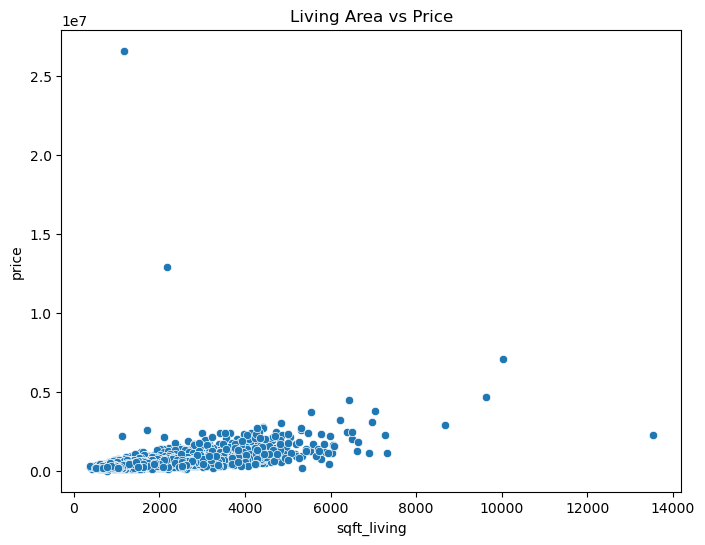

In [8]:
# Living Area vs Price
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='sqft_living',
    y='price'
)

plt.title("Living Area vs Price")
plt.savefig("../screenshots/living_area_vs_price.png")
plt.show()

### Bedrooms vs. Price

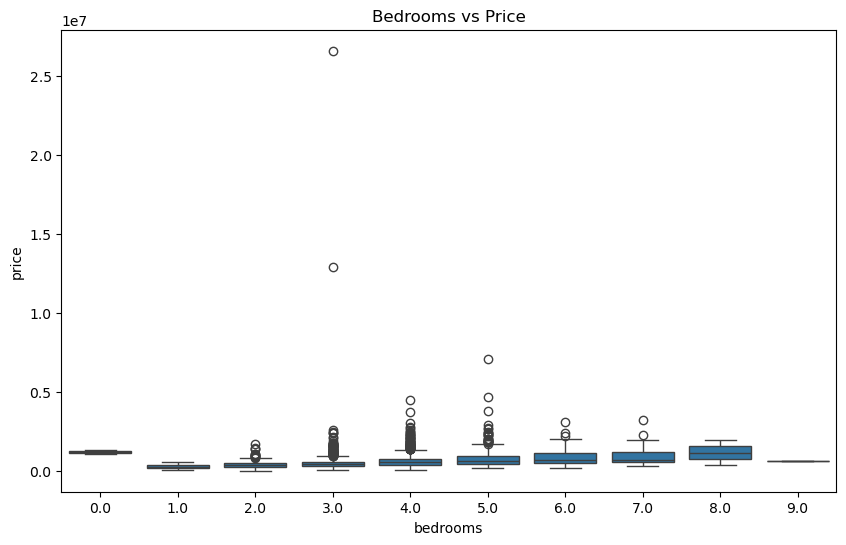

In [9]:
# Bedrooms vs Price
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='bedrooms',
    y='price'
)

plt.title("Bedrooms vs Price")
plt.savefig("../screenshots/bedrooms_vs_price.png")
plt.show()

### Top 10 Most Expensive Cities

Confirms location is a major price driver — worth encoding carefully, and later worth a dedicated location-based feature.

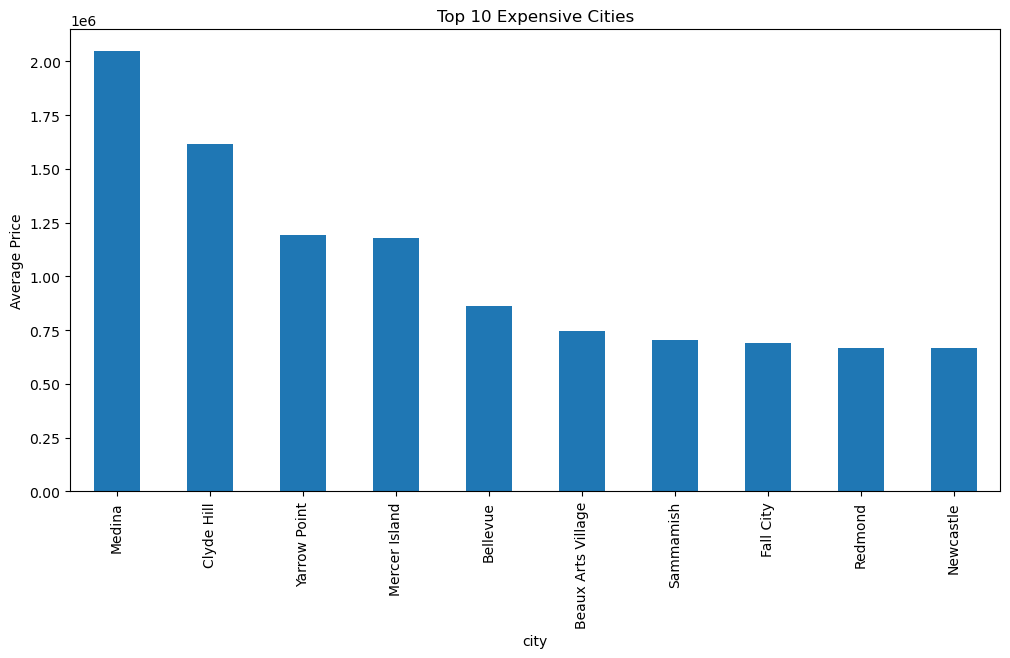

In [10]:
city_price = df.groupby('city')['price'].mean() \
               .sort_values(ascending=False) \
               .head(10)

plt.figure(figsize=(12,6))

city_price.plot(kind='bar')

plt.title("Top 10 Expensive Cities")
plt.ylabel("Average Price")

plt.savefig("../screenshots/top_cities.png")

plt.show()

## 6. Train/Test Split

Split into train and test sets before any target-dependent feature engineering, to avoid leaking test information into training features.

In [11]:
# Drop the raw price column since we will be predicting log_price
df_final = df.drop(columns=['price'])

# 1. Separate Features (X) and Target (y)
# We use 'log_price' as our target now!
X = df_final.drop(columns=['log_price'])
y = df_final['log_price']

# 2. Split into Train and Test sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 7. Feature Engineering: Location-Based Price Signal

`price_per_sqft_zipcode_avg` — the average price-per-square-foot for each zip code — was added after diagnosing that all models struggled most with high-value homes (see Section 14, Known Limitations). It's computed from **training data only** and mapped onto both sets, so it doesn't leak test information.

In [12]:
# ==========================================
# FEATURE ENGINEERING: price_per_sqft_zipcode_avg
# ==========================================

# Step 1: Build a temporary df_train with the ORIGINAL price (not log_price)
# so we can compute actual price-per-sqft. We pull 'price' from df_final
# using the same index as X_train.
train_price = df.loc[X_train.index, 'price']
train_sqft = X_train['sqft_living']

price_per_sqft_train = train_price / train_sqft

# Step 2: Group by zipcode (statezip) using training rows only
zipcode_avg_price_per_sqft = (
    pd.DataFrame({
        'statezip': X_train['statezip'],
        'price_per_sqft': price_per_sqft_train
    })
    .groupby('statezip')['price_per_sqft']
    .mean()
)

# Global fallback average, for any zipcode in test that never appeared in train
global_avg_price_per_sqft = price_per_sqft_train.mean()

# Step 3: Map onto train and test sets
X_train = X_train.copy()
X_test = X_test.copy()

X_train['price_per_sqft_zipcode_avg'] = (
    X_train['statezip'].map(zipcode_avg_price_per_sqft)
)
X_test['price_per_sqft_zipcode_avg'] = (
    X_test['statezip'].map(zipcode_avg_price_per_sqft)
    .fillna(global_avg_price_per_sqft)  # handles unseen zipcodes in test
)

print("New feature added. Sample values:")
print(X_train[['statezip', 'price_per_sqft_zipcode_avg']].head())
print(f"\nZipcodes in train: {X_train['statezip'].nunique()}")
print(f"Zipcodes in test not seen in train: "
      f"{(~X_test['statezip'].isin(zipcode_avg_price_per_sqft.index)).sum()}")

New feature added. Sample values:
      statezip  price_per_sqft_zipcode_avg
4134  WA 98126                  285.124847
2098  WA 98023                  142.677294
3706  WA 98022                  168.100746
4055  WA 98092                  154.114176
2153  WA 98005                  311.576920

Zipcodes in train: 77
Zipcodes in test not seen in train: 0


## 8. Target Encoding of Categorical Location Features

`city` and `statezip` are high-cardinality categoricals; target encoding maps each to the mean log-price for that category (fit on training data only).

In [13]:
categorical_cols = ['city', 'statezip']
encoder = TargetEncoder(cols=categorical_cols)

X_train_encoded = encoder.fit_transform(X_train, y_train)
X_test_encoded = encoder.transform(X_test)

## 9. Model Building & Hyperparameter Tuning

Four models are trained and compared: a Linear Regression baseline, then three tree ensembles (Random Forest, XGBoost, CatBoost), each tuned with `RandomizedSearchCV` so the reported results reflect a genuine search rather than manually guessed parameters.

### 9.1 Linear Regression (Baseline)

In [14]:
# ==========================================
# 1. LINEAR REGRESSION (BASELINE MODEL)
# ==========================================
lr_model = LinearRegression()
lr_model.fit(X_train_encoded, y_train)

# Predict on test data
y_pred_lr_log = lr_model.predict(X_test_encoded)

# Convert log predictions back to actual dollars using np.expm1
y_test_actual = np.expm1(y_test)
y_pred_lr_actual = np.expm1(y_pred_lr_log)

# Calculate Metrics for Linear Regression
mae_lr = mean_absolute_error(y_test_actual, y_pred_lr_actual)
rmse_lr = np.sqrt(mean_squared_error(y_test_actual, y_pred_lr_actual))
r2_lr = r2_score(y_test, y_pred_lr_log) # R2 is calculated on the scaled space

### 9.2 Random Forest

In [15]:
# ==========================================
# 2. RANDOM FOREST (HYPERPARAMETER TUNING)
# ==========================================
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.5, 1.0]
}

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)
search.fit(X_train_encoded, y_train)

print("Best Random Forest hyperparameters: ", search.best_params_)
print("Best CV score (neg MAE, log-space): ", search.best_score_)

# ==========================================
# 2b. RANDOM FOREST (FINAL MODEL, USING SEARCH RESULTS)
# ==========================================
rf_model = RandomForestRegressor(**search.best_params_, random_state=42)
rf_model.fit(X_train_encoded, y_train)

# Predict on test data
y_pred_rf_log = rf_model.predict(X_test_encoded)
y_pred_rf_actual = np.expm1(y_pred_rf_log)

# Calculate Metrics for Random Forest
mae_rf = mean_absolute_error(y_test_actual, y_pred_rf_actual)
rmse_rf = np.sqrt(mean_squared_error(y_test_actual, y_pred_rf_actual))
r2_rf = r2_score(y_test, y_pred_rf_log)

Best Random Forest hyperparameters:  {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 30}
Best CV score (neg MAE, log-space):  -0.15471241361700416


### 9.3 XGBoost

Tuned via `RandomizedSearchCV` on the same target-encoded features the final model uses, so the search results are directly applicable.

In [16]:
param_dist = {
    'max_depth': stats.randint(3, 11),          # samples from [3, 10]
    'learning_rate': stats.uniform(0.01, 0.19),  # samples from ~0.01 to 0.20
    'subsample': stats.uniform(0.5, 0.5),        # samples from 0.5 to 1.0
    'colsample_bytree': stats.uniform(0.5, 0.5), # samples from 0.5 to 1.0
    'n_estimators': stats.randint(100, 1001)     # samples from [100, 1000]
}

xgb_base = xgb.XGBRegressor(random_state=42)

random_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_encoded, y_train)

print("Best set of hyperparameters: ", random_search.best_params_)
print("Best CV score (neg MAE, log-space): ", random_search.best_score_)

Best set of hyperparameters:  {'colsample_bytree': np.float64(0.9165974558680822), 'learning_rate': np.float64(0.042939284166476695), 'max_depth': 3, 'n_estimators': 661, 'subsample': np.float64(0.831261142176991)}
Best CV score (neg MAE, log-space):  -0.1511207502704242


In [17]:
# ==========================================
# 3. XGBOOST (TUNED, USING RANDOMIZEDSEARCHCV RESULTS)
# ==========================================
xgb_model = xgb.XGBRegressor(**random_search.best_params_, random_state=42)
xgb_model.fit(X_train_encoded, y_train)

# Predict on test data
y_pred_xgb_log = xgb_model.predict(X_test_encoded)
y_pred_xgb_actual = np.expm1(y_pred_xgb_log)

# Calculate Metrics for XGBoost
mae_xgb = mean_absolute_error(y_test_actual, y_pred_xgb_actual)
rmse_xgb = np.sqrt(mean_squared_error(y_test_actual, y_pred_xgb_actual))
r2_xgb = r2_score(y_test, y_pred_xgb_log)

### 9.4 CatBoost

CatBoost handles categorical columns (`city`, `statezip`) natively, so it's trained on the raw (non-target-encoded) feature set instead.

In [18]:
# Get the indices of categorical columns instead of using column names
# This avoids the cloning issue with RandomizedSearchCV
categorical_features_indices = [X_train.columns.get_loc(col) for col in ['city', 'statezip']]

cb_param_dist = {
    'depth': stats.randint(4, 10),
    'learning_rate': stats.uniform(0.01, 0.19),
    'l2_leaf_reg': stats.uniform(1, 9),
    'iterations': stats.randint(300, 1001)
}

# Remove cat_features from constructor to avoid cloning issues
cb_base = CatBoostRegressor(
    random_state=42,
    verbose=0
)

cb_search = RandomizedSearchCV(
    cb_base,
    param_distributions=cb_param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

# Pass categorical features to fit method instead of constructor
cb_search.fit(X_train, y_train, cat_features=categorical_features_indices)

print("Best CatBoost hyperparameters: ", cb_search.best_params_)
print("Best CV score (neg MAE, log-space): ", cb_search.best_score_)

# Train final model with best params
cb_model = CatBoostRegressor(
    **cb_search.best_params_,
    random_state=42,
    verbose=0
)
# Specify categorical features in fit method for final model too
cb_model.fit(X_train, y_train, cat_features=categorical_features_indices)

# Predict on test data
y_pred_cb_log = cb_model.predict(X_test)
y_pred_cb_actual = np.expm1(y_pred_cb_log)

# Calculate Metrics for CatBoost
mae_cb = mean_absolute_error(y_test_actual, y_pred_cb_actual)
rmse_cb = np.sqrt(mean_squared_error(y_test_actual, y_pred_cb_actual))
r2_cb = r2_score(y_test, y_pred_cb_log)

Best CatBoost hyperparameters:  {'depth': 4, 'iterations': 678, 'l2_leaf_reg': np.float64(1.6664018656068134), 'learning_rate': np.float64(0.0781084884234118)}
Best CV score (neg MAE, log-space):  -0.15144727334487712


## 10. Model Evaluation

Compare all four models on Mean Absolute Error, Root Mean Squared Error, and R².

In [19]:
# ==========================================
# GENERATING PERFORMANCE REPORT
# ==========================================
report_df = pd.DataFrame({
    'Evaluation Metric': ['Mean Absolute Error (MAE)', 'Root Mean Squared Error (RMSE)', 'R² Score (Variance Explained)'],
    'Linear Regression': [f"${mae_lr:,.2f}", f"${rmse_lr:,.2f}", f"{r2_lr*100:.1f}%"],
    'Random Forest': [f"${mae_rf:,.2f}", f"${rmse_rf:,.2f}", f"{r2_rf*100:.1f}%"],
    'XGBoost': [f"${mae_xgb:,.2f}", f"${rmse_xgb:,.2f}", f"{r2_xgb*100:.1f}%"],
    'CatBoost': [f"${mae_cb:,.2f}", f"${rmse_cb:,.2f}", f"{r2_cb*100:.1f}%"]
})

print("=========================================================")
print("          MODEL PERFORMANCE COMPARISON REPORT            ")
print("=========================================================")
print(report_df.to_string(index=False))

          MODEL PERFORMANCE COMPARISON REPORT            
             Evaluation Metric Linear Regression Random Forest     XGBoost    CatBoost
     Mean Absolute Error (MAE)       $131,190.05    $95,899.61  $92,897.85  $92,582.55
Root Mean Squared Error (RMSE)       $660,682.09   $202,017.55 $198,526.65 $198,331.28
 R² Score (Variance Explained)             72.4%         76.8%       77.3%       76.7%


## 11. Residual Analysis: Where Are the Errors?

Aggregate R²/MAE hide *where* a model struggles. Plotting residuals against actual price, and breaking error down by price bracket, shows that all models are consistently accurate in the $300K–$723K range (~12–14% error) but roughly 3x worse in dollar terms for homes above $723K. This diagnosis directly motivated the `price_per_sqft_zipcode_avg` feature in Section 7.

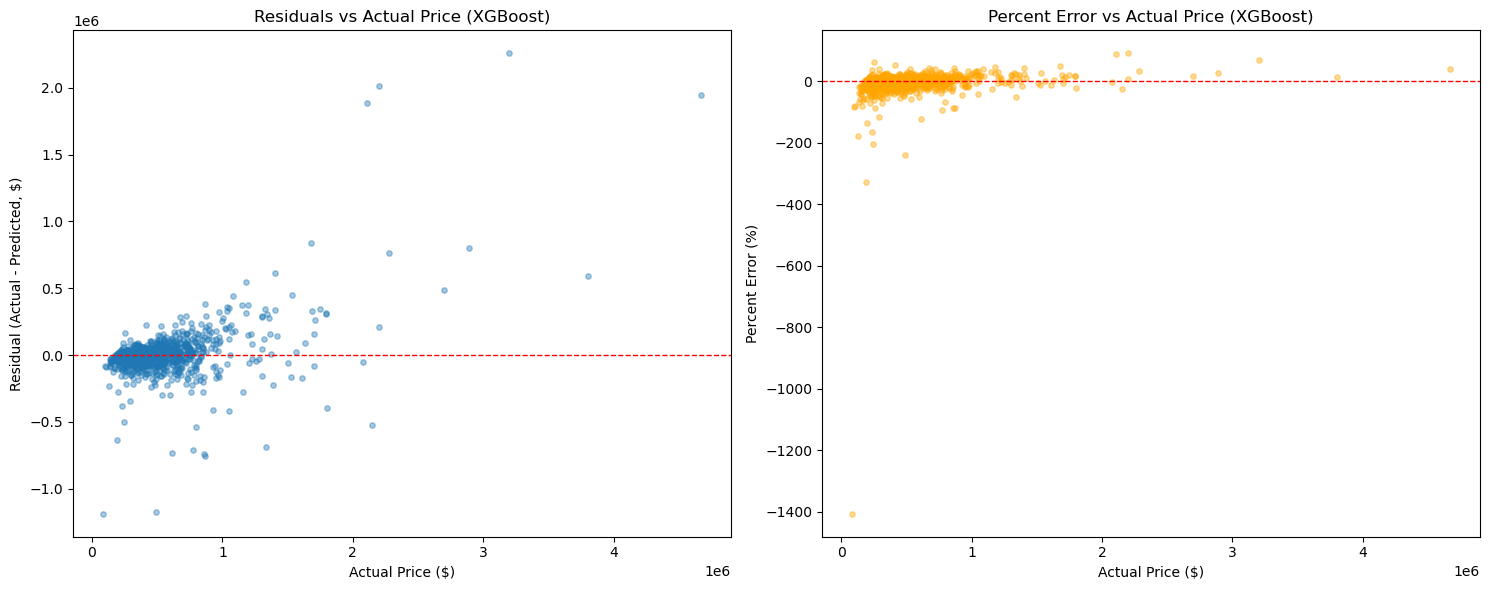

In [20]:
# ==========================================
# RESIDUAL DIAGNOSTICS (XGBoost)
# ==========================================
residuals_xgb = y_test_actual - y_pred_xgb_actual
pct_error_xgb = residuals_xgb / y_test_actual * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(y_test_actual, residuals_xgb, alpha=0.4, s=15)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Residual (Actual - Predicted, $)')
axes[0].set_title('Residuals vs Actual Price (XGBoost)')

axes[1].scatter(y_test_actual, pct_error_xgb, alpha=0.4, s=15, color='orange')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Actual Price ($)')
axes[1].set_ylabel('Percent Error (%)')
axes[1].set_title('Percent Error vs Actual Price (XGBoost)')

plt.tight_layout()
plt.savefig("../screenshots/residuals_vs_price.png")
plt.show()


In [21]:
# ==========================================
# ERROR BY PRICE BRACKET - RF vs XGBoost vs CatBoost
# ==========================================
price_bins = pd.qcut(y_test_actual, q=5)

def bracket_errors(y_actual, y_pred, price_bins, model_name):
    residuals = y_actual - y_pred
    pct_error = (residuals / y_actual * 100).abs()
    df_temp = pd.DataFrame({
        'abs_error': residuals.abs(),
        'pct_error': pct_error,
        'price_bracket': price_bins
    })
    summary = df_temp.groupby('price_bracket', observed=True).agg(
        count=('abs_error', 'size'),
        mean_abs_error=('abs_error', 'mean'),
        mean_pct_error=('pct_error', 'mean')
    )
    summary.columns = [f'{model_name}_{col}' if col != 'count' else 'count'
                        for col in summary.columns]
    return summary

rf_brackets = bracket_errors(y_test_actual, y_pred_rf_actual, price_bins, 'RF')
xgb_brackets = bracket_errors(y_test_actual, y_pred_xgb_actual, price_bins, 'XGB')
cb_brackets = bracket_errors(y_test_actual, y_pred_cb_actual, price_bins, 'CB')

comparison = rf_brackets.join(
    xgb_brackets.drop(columns='count')
).join(
    cb_brackets.drop(columns='count')
)

comparison = comparison[[
    'count',
    'RF_mean_abs_error', 'XGB_mean_abs_error', 'CB_mean_abs_error',
    'RF_mean_pct_error', 'XGB_mean_pct_error', 'CB_mean_pct_error'
]]

print("=========================================================")
print("     ERROR BY PRICE BRACKET - RF vs XGBoost vs CatBoost   ")
print("=========================================================")
print(comparison.to_string())


     ERROR BY PRICE BRACKET - RF vs XGBoost vs CatBoost   
                        count  RF_mean_abs_error  XGB_mean_abs_error  CB_mean_abs_error  RF_mean_pct_error  XGB_mean_pct_error  CB_mean_pct_error
price_bracket                                                                                                                                    
(84349.999, 300000.0]     186       58115.244841        58629.330134       60796.661999          31.166560           31.372748          32.627040
(300000.0, 415000.0]      182       48324.431251        46447.549980       46813.554341          13.573908           13.049732          13.156927
(415000.0, 539000.0]      179       66355.287146        61055.664220       62929.923254          13.795505           12.731661          13.134700
(539000.0, 723243.75]     182       77549.839403        75699.169891       80466.243343          12.486470           12.194073          12.969281
(723243.75, 4668000.0]    182      229496.672271       222885.806

## 12. Ensembling XGBoost + CatBoost

The bracket analysis above shows XGBoost and CatBoost make partially different errors across price ranges rather than the same mistakes. Averaging their predictions (in log-space) tests whether those errors partially cancel out.

In [22]:
# ==========================================
# SIMPLE ENSEMBLE: XGBoost + CatBoost (averaged)
# ==========================================
# Average in log-space (same space the models were trained/optimized in)
y_pred_ensemble_log = (y_pred_xgb_log + y_pred_cb_log) / 2
y_pred_ensemble_actual = np.expm1(y_pred_ensemble_log)

mae_ensemble = mean_absolute_error(y_test_actual, y_pred_ensemble_actual)
rmse_ensemble = np.sqrt(mean_squared_error(y_test_actual, y_pred_ensemble_actual))
r2_ensemble = r2_score(y_test, y_pred_ensemble_log)

print(f"Ensemble (XGB + CatBoost avg) MAE:  ${mae_ensemble:,.2f}")
print(f"Ensemble (XGB + CatBoost avg) RMSE: ${rmse_ensemble:,.2f}")
print(f"Ensemble (XGB + CatBoost avg) R²:   {r2_ensemble*100:.1f}%")

# Add to your report_df for direct comparison
report_df['Ensemble (XGB+CB)'] = [
    f"${mae_ensemble:,.2f}", f"${rmse_ensemble:,.2f}", f"{r2_ensemble*100:.1f}%"
]
print(report_df.to_string(index=False))

Ensemble (XGB + CatBoost avg) MAE:  $91,590.93
Ensemble (XGB + CatBoost avg) RMSE: $196,848.74
Ensemble (XGB + CatBoost avg) R²:   77.3%
             Evaluation Metric Linear Regression Random Forest     XGBoost    CatBoost Ensemble (XGB+CB)
     Mean Absolute Error (MAE)       $131,190.05    $95,899.61  $92,897.85  $92,582.55        $91,590.93
Root Mean Squared Error (RMSE)       $660,682.09   $202,017.55 $198,526.65 $198,331.28       $196,848.74
 R² Score (Variance Explained)             72.4%         76.8%       77.3%       76.7%             77.3%


## 13. Feature Importance Analysis

Using Random Forest's built-in importances to see which features drive price predictions most.

In [23]:
importance = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
2,sqft_living,0.301659
11,statezip,0.295330
15,price_per_sqft_zipcode_avg,0.134349
8,sqft_above,0.085565
10,city,0.060609
1,bathrooms,0.033684
3,sqft_lot,0.021762
13,house_age,0.018471
6,view,0.014465
9,sqft_basement,0.010851


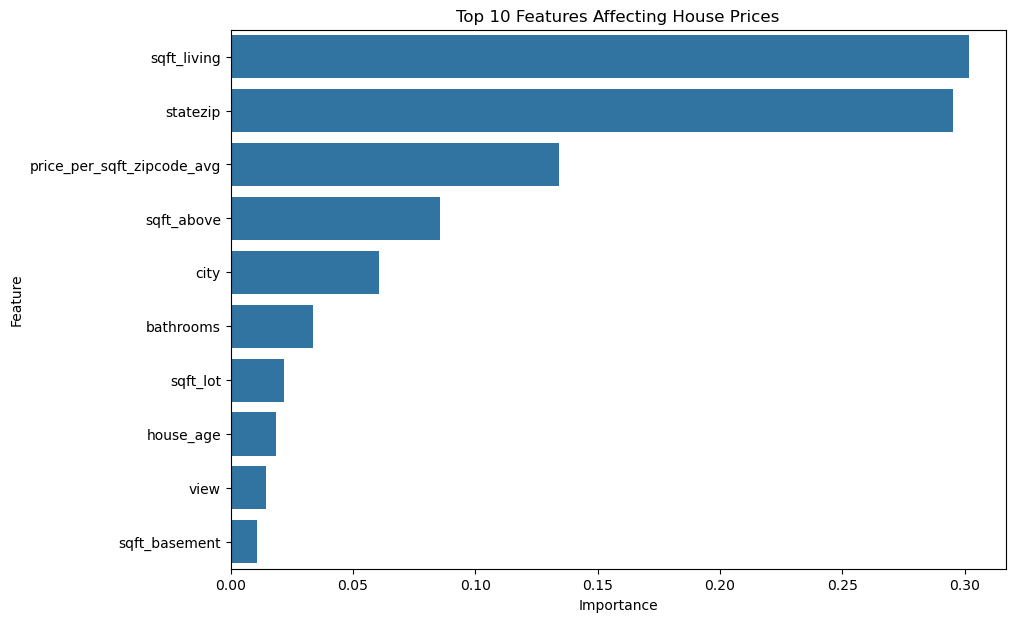

In [24]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Features Affecting House Prices")

plt.savefig("../screenshots/feature_importance.png")

plt.show()

## 14. Partial Dependence: Bedrooms & Floors

Manual testing in the app showed price occasionally decreasing with more bedrooms/floors, which seemed counterintuitive. A partial dependence plot — isolating each feature's effect while holding all others fixed — confirms this is a genuine pattern the model learned, not an artifact of changing correlated inputs (e.g., bedrooms without living area) together. Price rises with bedroom count up to ~4, then declines for larger homes; a similar pattern holds for floors. This likely reflects that very high bedroom/floor counts in this dataset tend to belong to a different, lower-value housing segment (larger suburban/rural homes) rather than reflecting a true causal penalty for adding rooms.

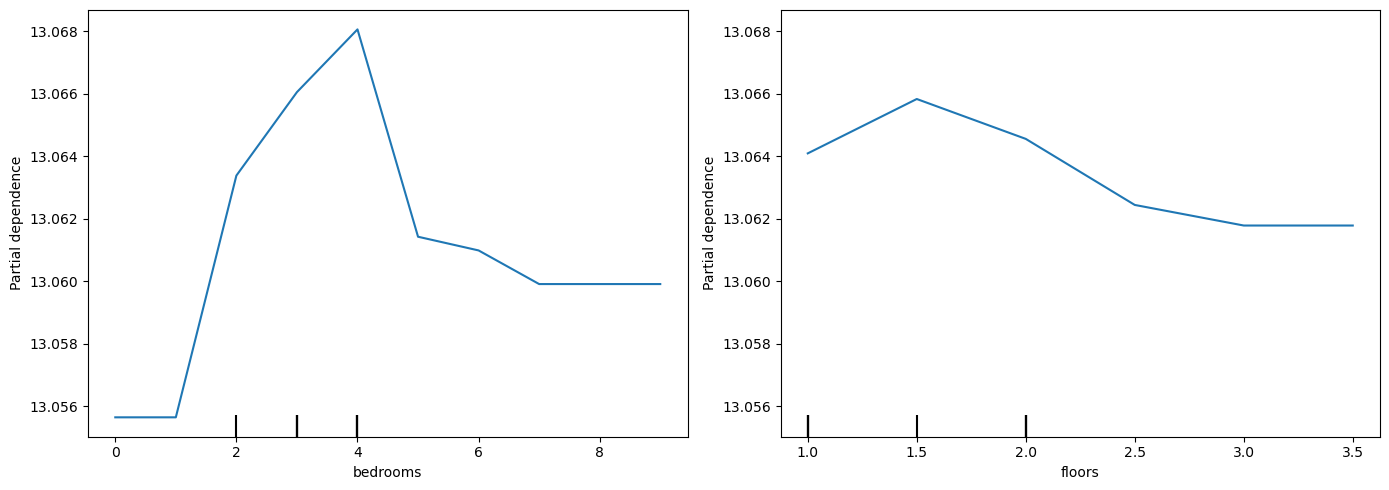

In [26]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
PartialDependenceDisplay.from_estimator(
    rf_model, X_train_encoded, ['bedrooms', 'floors'], ax=ax
)
plt.tight_layout()
plt.savefig("../screenshots/partial_dependence_bedrooms_floors.png")
plt.show()

## 15. Saving the Final Model

Both models, plus the target encoder and the zip-code price-per-sqft lookup table, are persisted so the ensemble can be reloaded without retraining.

In [27]:
# ==========================================
# SAVE FINAL MODELS
# ==========================================
pickle.dump(xgb_model, open('../models/house_price_xgb_model.pkl', 'wb'))
pickle.dump(cb_model, open('../models/house_price_cb_model.pkl', 'wb'))
pickle.dump(encoder, open('../models/target_encoder.pkl', 'wb'))

pickle.dump(zipcode_avg_price_per_sqft, open('../models/zipcode_avg_price_per_sqft.pkl', 'wb'))
pickle.dump(global_avg_price_per_sqft, open('../models/global_avg_price_per_sqft.pkl', 'wb'))

## 16. Example Prediction on New Data

Reload the saved artifacts and predict the price of a sample house to confirm the full pipeline works end-to-end.

In [28]:
# ==========================================
# LOAD AND PREDICT ON A NEW SAMPLE
# ==========================================
xgb_loaded = pickle.load(open('../models/house_price_xgb_model.pkl', 'rb'))
cb_loaded = pickle.load(open('../models/house_price_cb_model.pkl', 'rb'))
encoder_loaded = pickle.load(open('../models/target_encoder.pkl', 'rb'))

sample = pd.DataFrame([{
    'bedrooms': 4, 'bathrooms': 2.5, 'sqft_living': 2200, 'sqft_lot': 8000,
    'floors': 2.0, 'waterfront': 0, 'view': 0, 'condition': 3,
    'sqft_above': 2200, 'sqft_basement': 0,
    'city': 'Seattle', 'statezip': 'WA 98119',
    'month_sold': 5, 'house_age': 15, 'is_renovated': 0
}])

# Add price_per_sqft_zipcode_avg using the SAME lookup table built from training data
sample['price_per_sqft_zipcode_avg'] = (
    sample['statezip'].map(zipcode_avg_price_per_sqft)
    .fillna(global_avg_price_per_sqft)
)

# XGBoost needs target-encoded features
sample_encoded = encoder_loaded.transform(sample)
xgb_pred_log = xgb_loaded.predict(sample_encoded)

# CatBoost needs raw features (native categorical handling)
cb_pred_log = cb_loaded.predict(sample)

# Average in log-space, then convert back to dollars
ensemble_log = (xgb_pred_log + cb_pred_log) / 2
prediction_actual = np.expm1(ensemble_log)

print("Predicted House Price (Ensemble):", f"${prediction_actual[0]:,.2f}")

Predicted House Price (Ensemble): $955,053.29


## 17. Conclusions

## Final Results

Four models were evaluated, and their predictions were also combined into an ensemble:

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | $131,190.05 | $660,682.09 | 72.4% |
| Random Forest | $95,899.61 | $202,017.55 | 76.8% |
| XGBoost (tuned) | $92,897.85 | $198,526.65 | 77.3% |
| CatBoost (tuned) | $92,582.55 | $198,331.28 | 76.7% |
| **Ensemble (XGBoost + CatBoost, averaged)** | **$91,590.93** | **$196,848.74** | **77.3%** |

The final model is the **XGBoost + CatBoost ensemble** (simple average of predictions in log-space). It produced the lowest error on every metric, since the two models make partially different errors that cancel out when combined — confirmed by a price-bracket analysis showing XGBoost performs marginally better in the $415K-$723K range while CatBoost performs notably better above $723K.

## Key Findings Along the Way

Several issues were identified and corrected during development, which meaningfully changed the results from the first version of this notebook:

- **A prediction bug** caused XGBoost's evaluation to silently reuse Random Forest's predictions (`rf_model.predict(...)` instead of `xgb_model.predict(...)`), making the two models appear identical. Fixing this revealed XGBoost's true, and better, performance.
- **The XGBoost hyperparameter search (`RandomizedSearchCV`) was not connected to the final model** — the final model used manually hardcoded parameters instead of `random_search.best_params_`. The search was also being run on a different feature encoding than the final model used. Both were fixed so tuning results are actually used.
- **Residual analysis by price bracket** showed that all models had roughly consistent ~12-14% error in the $300K-$723K range, but error nearly tripled (in dollar terms) for homes above $723K — the model systematically struggled most with high-value homes.
- **A targeted feature, `price_per_sqft_zipcode_avg`** (average price-per-square-foot for each zip code, computed from training data only), was engineered in response to that finding. It improved MAE, RMSE, and R² for every model, confirming the earlier performance ceiling was a missing-feature problem rather than a model-choice problem.

## Important Factors Affecting House Prices

- Living area (`sqft_living`)
- Number of bathrooms
- Waterfront status
- House age
- View quality
- Location, captured via `city`/`statezip` (target-encoded) and the engineered `price_per_sqft_zipcode_avg` feature

## Known Limitations

- **High-value homes (>$723K) remain the weakest segment** — even after feature engineering, dollar error in this bracket is roughly 3x that of the mid-market brackets. A segmented or two-stage model (separate luxury-home model) was considered as a next step but not implemented, since the mid-market gains already achieved represent the best effort-to-impact ratio for this pass.
- Percent error is high for the lowest price bracket (~$84K-$300K), but this is partly a metric artifact of small denominators rather than a genuine model weakness — worth revisiting with dollar-based error rather than percent error if extended.
- The `price_per_sqft_zipcode_avg` feature and target encoding both carry a mild same-row leakage risk (each row's own price contributes to its own zip code's average). A more rigorous version would use K-fold target encoding.

## Possible Future Improvements

- K-fold (out-of-fold) target encoding to remove leakage risk in `price_per_sqft_zipcode_avg` and the city/statezip encoding
- A segmented or two-stage model specifically for high-value homes
- LightGBM as an additional ensemble member
- Cross-validated performance estimates (currently based on a single train/test split)
- Streamlit deployment of the final ensemble model for interactive predictions

## Workflow Summary

This project demonstrates an end-to-end machine learning workflow including:

- Data cleaning and feature engineering
- Exploratory data analysis
- Model training across multiple algorithms (Linear Regression, Random Forest, XGBoost, CatBoost)
- Hyperparameter tuning with `RandomizedSearchCV`
- Model evaluation and diagnostic residual analysis
- Targeted feature engineering based on diagnosed error patterns
- Model ensembling
- Model persistence (pickling) for deployment
